In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

# 데이터 로드
df = pd.read_csv('/content/drive/MyDrive/취업 포폴/Olist 비즈니스 데이터 분석/customer_summary_final.csv')


In [3]:
print(df.head())

                        customer_id          first_order           last_order  \
0  0000366f3b9a7992bf8c76cfdf3221e2  2018-05-10 10:56:27  2018-05-10 10:56:27   
1  0000b849f77a49e4a4ce2b2a4ca5be3f  2018-05-07 11:11:27  2018-05-07 11:11:27   
2  0000f46a3911fa3c0805444483337064  2017-03-10 21:05:03  2017-03-10 21:05:03   
3  0000f6ccb0745a6a4b88665a16c9f078  2017-10-12 20:29:41  2017-10-12 20:29:41   
4  0004aac84e0df4da2b147fca70cf8255  2017-11-14 19:45:42  2017-11-14 19:45:42   

   order_count  avg_order_gap reference_date  days_since_last  churn_90  \
0            1            NaN     2018-10-30              173         1   
1            1            NaN     2018-10-30              176         1   
2            1            NaN     2018-10-30              599         1   
3            1            NaN     2018-10-30              383         1   
4            1            NaN     2018-10-30              350         1   

   churn_dynamic  total_revenue  median_order_gap  
0         

In [4]:
df['avg_order_gap'].describe()

,avg_order_gap
count,2801.000000
mean,80.600209
std,107.915817
min,0.000000
25%,0.000000
50%,32.000000
75%,125.000000
max,608.000000


In [ ]:
df['order_count'].value_counts()

,count
order_count,
1,90557
2,2573
3,181
4,28
5,9
6,5
7,3
9,1
15,1


In [ ]:
df['days_since_last'].describe()

,days_since_last
count,93358.000000
mean,299.478877
std,152.595054
min,62.000000
25%,176.000000
50%,280.000000
75%,408.000000
max,775.000000


#이탈 기준 retention, 배수별 churn rate 비교


In [ ]:
# 분포 계산
dist = (
    df.groupby('days_since_last')
    .size()
    .reset_index(name='customer_cnt')
    .sort_values('days_since_last')
)

# 비율(ratio)
dist['ratio'] = dist['customer_cnt'] / dist['customer_cnt'].sum()

#누적 비율
dist['cum_ratio'] = dist['ratio'].cumsum()

dist.head(20)

,days_since_last,customer_cnt,ratio,cum_ratio
0,62,11,0.000118,0.000118
1,63,39,0.000418,0.000536
2,64,66,0.000707,0.001243
3,65,73,0.000782,0.002024
4,66,69,0.000739,0.002764
5,67,96,0.001028,0.003792
6,68,142,0.001521,0.005313
7,69,183,0.001960,0.007273
8,70,238,0.002549,0.009822
9,71,251,0.002689,0.012511


In [ ]:
dist[dist['cum_ratio'] >= 0.8].head()
# dist[dist['cum_ratio'] >= 0.9].head()
# dist[dist['cum_ratio'] >= 0.95].head()

,days_since_last,customer_cnt,ratio,cum_ratio
382,444,84,0.000900,0.800713
383,445,125,0.001339,0.802052
384,446,144,0.001542,0.803595
385,447,138,0.001478,0.805073
386,448,142,0.001521,0.806594


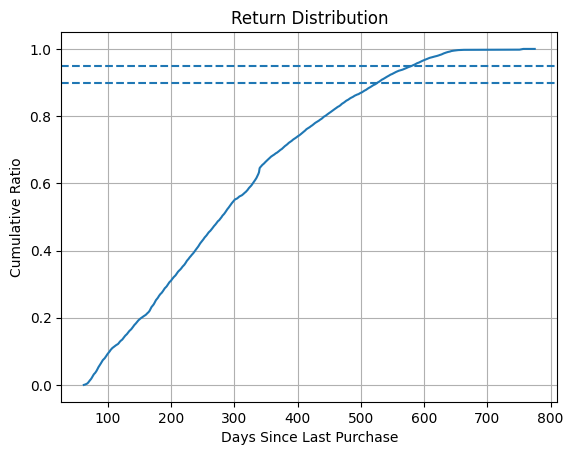

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(dist['days_since_last'], dist['cum_ratio'])

plt.axhline(0.9, linestyle='--')
plt.axhline(0.95, linestyle='--')

plt.xlabel('Days Since Last Purchase')
plt.ylabel('Cumulative Ratio')
plt.title('Return Distribution')

plt.grid()
plt.show()

In [ ]:
# days_since_last 기준 분위수 계산
quantiles = df['days_since_last'].quantile([0.5, 0.6, 0.7, 0.8]).reset_index()
quantiles.columns = ['quantile', 'days']

print(quantiles)

   quantile   days
0       0.5  280.0
1       0.6  330.0
2       0.7  374.0
3       0.8  444.0


In [ ]:
# 결과 저장 리스트
results = []

# multiplier 1~5
for m in range(1, 6):
    churn = (df['days_since_last'] > df['avg_order_gap'] * m).astype(int)

    churn_rate = churn.mean()

    results.append({
        'multiplier': m,
        'churn_rate': churn_rate
    })
churn_df = pd.DataFrame(results)
churn_df

,multiplier,churn_rate
0,1,0.025343
1,2,0.021712
2,3,0.019527
3,4,0.018038
4,5,0.016871


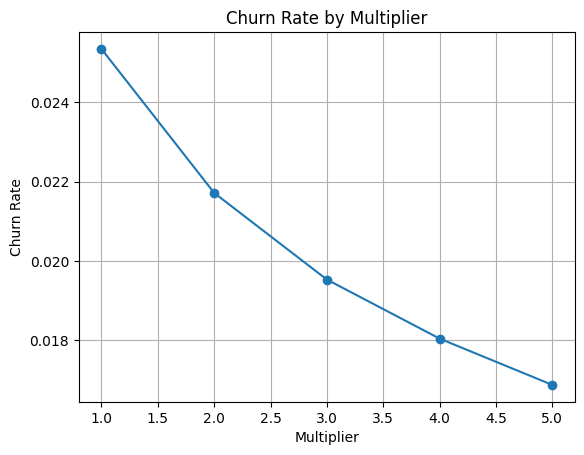

In [ ]:
import matplotlib.pyplot as plt

plt.plot(churn_df['multiplier'], churn_df['churn_rate'], marker='o')
plt.xlabel('Multiplier')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Multiplier')
plt.grid()

plt.show()

# 세그먼트 - 90일 기준



### lifecycle segment

In [ ]:
# def lifecycle_segment(row):
#     r = row['days_since_last']
#     g = row['avg_order_gap']
#     orders = row['order_count']

#     # NEW (판단 유예)
#     if orders == 1 and r <= 90:
#         return 'New'

#     # ACTIVE
#     elif r <= g * 1.5:
#         return 'Active'

#     # DORMANT
#     elif r <= g * 3:
#         return 'Dormant'

#     # CHURN
#     else:
#         return 'Churn'
# df['lifecycle'] = df.apply(lifecycle_segment, axis=1)

In [3]:
def lifecycle_segment(row):
    r = row['days_since_last']
    g = row['avg_order_gap']
    orders = row['order_count']

    # 1. 첫 구매 고객
    if orders == 1:
        if r <= 90:
            return 'New'
        elif r <= 180:
            return 'Early Risk'
        else:
            return 'Churn'

    # 2. 재구매 고객
    else:
        g = max(g, 30)

        if r <= g * 1.5:
            return 'Active'
        elif r <= g * 3:
            return 'Dormant'
        else:
            return 'Churn'
df['lifecycle'] = df.apply(lifecycle_segment, axis=1)

In [4]:
lifecycle_dist = (
    df['lifecycle']
    .value_counts(normalize=True)
    .reset_index()
)

lifecycle_dist.columns = ['lifecycle', 'ratio']
lifecycle_dist

,lifecycle,ratio
0,Churn,0.735395
1,Early Risk,0.188072
2,New,0.065447
3,Active,0.006641
4,Dormant,0.004445


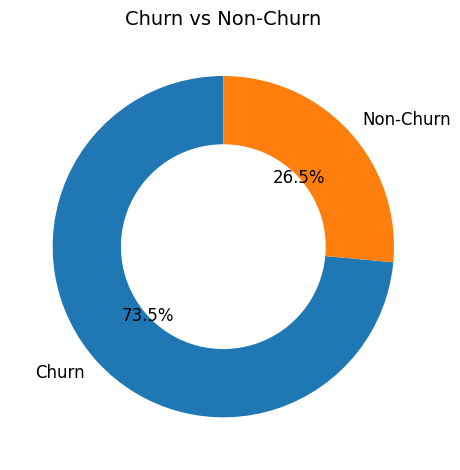

In [7]:
import matplotlib.pyplot as plt

# churn vs non-churn
churn_binary = df['lifecycle'].apply(
    lambda x: 'Churn' if x == 'Churn' else 'Non-Churn'
)

churn_dist = churn_binary.value_counts(normalize=True)

# 도넛 파이
plt.figure()
plt.pie(
    churn_dist,
    labels=churn_dist.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4},
    textprops={'fontsize': 12}
)

plt.title('Churn vs Non-Churn', fontsize=14)
plt.tight_layout()
plt.show()


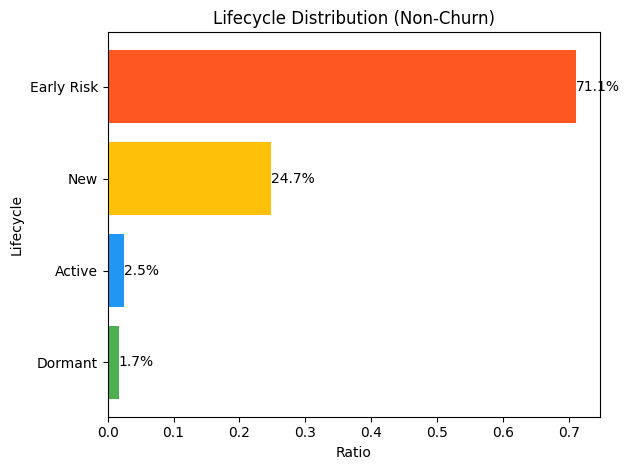

In [27]:
import matplotlib.pyplot as plt

# 1. churn 제외
non_churn = df[df['lifecycle'] != 'Churn']

# 2. 비율 계산
non_churn_dist = (
    non_churn['lifecycle']
    .value_counts(normalize=True)
    .sort_values(ascending=True)  # 가로 그래프라서 작은 값 위로
)

# 3. 색상 지정
colors = ['#4CAF50', '#2196F3', '#FFC107', '#FF5722']  # Green, Blue, Yellow, Red

# 4. 가로 막대그래프
plt.figure()
plt.barh(non_churn_dist.index, non_churn_dist.values, color=colors)

# 5. 퍼센트 라벨
for i, v in enumerate(non_churn_dist.values):
    plt.text(v, i, f'{v:.1%}', va='center')

plt.title('Lifecycle Distribution (Non-Churn)')
plt.xlabel('Ratio')
plt.ylabel('Lifecycle')

plt.tight_layout()
plt.show()

### value segment


In [5]:
#2. value(매출 기준 분위수)
q70 = df['total_revenue'].quantile(0.7)
q30 = df['total_revenue'].quantile(0.3)

def value_segment(x):
    if x >= q70:
        return 'VIP'
    elif x <= q30:
        return 'Low'
    else:
        return 'Mid'

df['value_segment'] = df['total_revenue'].apply(value_segment)

value_dist = df['value_segment'].value_counts(normalize=True).reset_index()
value_dist.columns = ['segment', 'ratio']

print(value_dist)

  segment     ratio
0     Mid  0.399859
1     VIP  0.300124
2     Low  0.300017


In [9]:
#매출 평균
df.groupby('value_segment')['total_revenue'].mean()

,total_revenue
value_segment,
Low,47.424612
Mid,110.702103
VIP,356.945589


In [10]:
pd.crosstab(df['value_segment'], df['churn_90'], normalize='index')

churn_90,0,1
value_segment,,
Low,0.070013,0.929987
Mid,0.067694,0.932306
VIP,0.065027,0.934973


In [11]:
pd.crosstab(df['value_segment'], df['churn_dynamic'], normalize='index')

churn_dynamic,0,1
value_segment,,
Low,0.997822,0.002178
Mid,0.985829,0.014171
VIP,0.955994,0.044006


In [12]:
pd.crosstab(df['value_segment'], df['lifecycle'], normalize='index')

lifecycle,Active,Churn,Dormant,Early Risk,New
value_segment,,,,,
Low,0.000607,0.742618,0.000321,0.186761,0.069692
Mid,0.004259,0.737102,0.002491,0.189794,0.066354
VIP,0.015846,0.725900,0.011171,0.187087,0.059995


### behavior segment

In [ ]:
# #3. behavior(Fast/normal/Slow)
# def behavior_segment(row):
#     g = row['avg_order_gap']

#     if g <= 30:
#         return 'Fast'

#     elif g <= 90:
#         return 'Normal'

#     else:
#         return 'Slow'

# df['behavior'] = df.apply(behavior_segment, axis=1)

In [6]:
def behavior_segment(row):
    g = row['avg_order_gap']
    orders = row['order_count']

    # 단일 구매 고객 제외
    if orders == 1:
        return 'Single'

    # gap 보정
    g = max(g, 30)

    if g <= 30:
        return 'Fast'
    elif g <= 90:
        return 'Normal'
    else:
        return 'Slow'
df['behavior'] = df.apply(behavior_segment, axis=1)

In [7]:
behavior_dist = (
    df['behavior']
    .value_counts(normalize=True)
    .reset_index()
)

behavior_dist.columns = ['behavior', 'ratio']
behavior_dist

,behavior,ratio
0,Single,0.969997
1,Fast,0.014760
2,Slow,0.009555
3,Normal,0.005688


In [15]:
behavior_dist_excl_single = (
    df[df['order_count'] > 1]['behavior']
    .value_counts(normalize=True)
    .reset_index()
)

behavior_dist_excl_single.columns = ['behavior', 'ratio']
behavior_dist_excl_single

,behavior,ratio
0,Fast,0.491967
1,Slow,0.318458
2,Normal,0.189575


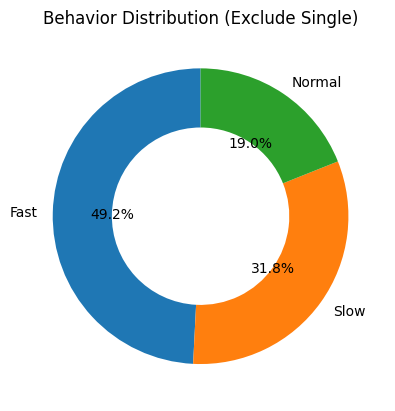

In [28]:
import matplotlib.pyplot as plt

# single 제외
behavior_dist_excl_single = (
    df[df['order_count'] > 1]['behavior']
    .value_counts(normalize=True)
)

# 도넛 파이
plt.figure()
plt.pie(
    behavior_dist_excl_single,
    labels=behavior_dist_excl_single.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}  # 도넛 형태
)

plt.title('Behavior Distribution (Exclude Single)')
plt.show()

In [16]:
# avg_order_gap 평균 확인
df.groupby('behavior')['avg_order_gap'].mean()

,avg_order_gap
behavior,
Fast,5.384222
Normal,56.141669
Single,NaN
Slow,211.357063


In [17]:
# 교차 분석
cross_tab = pd.crosstab(
    df['lifecycle'],
    df['behavior'],
    normalize='index'
)

cross_tab

behavior,Fast,Normal,Single,Slow
lifecycle,,,,
Active,0.000000,0.051613,0.000000,0.948387
Churn,0.019197,0.005520,0.974277,0.001005
Dormant,0.144578,0.289157,0.000000,0.566265
Early Risk,0.000000,0.000000,1.000000,0.000000
New,0.000000,0.000000,1.000000,0.000000


### churn_type segment

In [6]:
# def churn_type_segment(row):
#     if row['lifecycle'] != 'Churn':
#         return 'None'

#     elif row['churn_90'] == 1 and row['order_count'] == 1:
#         return 'Early'

#     else:
#         return 'Loyal'


# df['churn_type'] = df.apply(churn_type_segment, axis=1)
# churn_type_dist = df['churn_type'].value_counts(normalize=True).reset_index()
# churn_type_dist.columns = ['churn_type', 'ratio']

# churn_type_dist

,churn_type,ratio
0,Early,0.716479
1,None,0.264605
2,Loyal,0.018916


In [8]:
def churn_type_segment(row):

    if row['lifecycle'] != 'Churn':
        return 'None'

    # 첫 구매 후 이탈
    elif row['order_count'] == 1:
        return 'Early'

    # 재구매 고객 이탈
    else:
        return 'Loyal'
df['churn_type'] = df.apply(churn_type_segment, axis=1)
churn_type_dist = df['churn_type'].value_counts(normalize=True).reset_index()
churn_type_dist.columns = ['churn_type', 'ratio']

churn_type_dist

,churn_type,ratio
0,Early,0.716479
1,None,0.264605
2,Loyal,0.018916


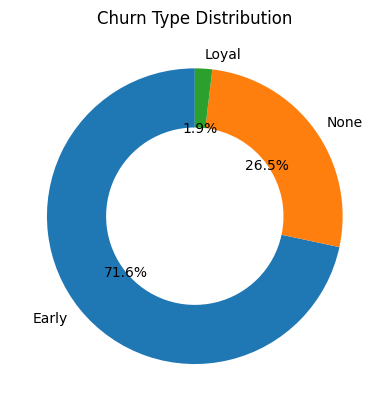

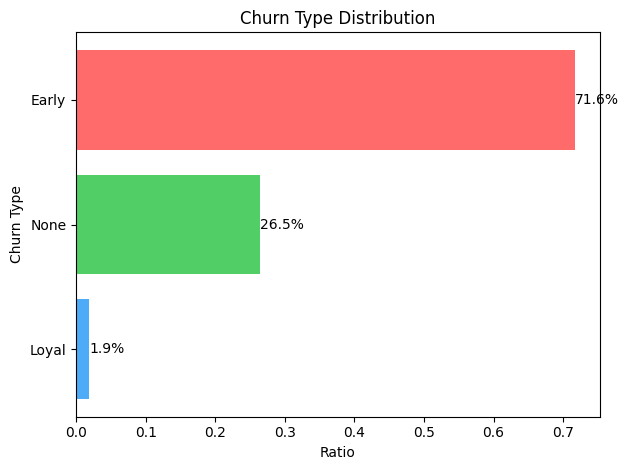

In [30]:
import matplotlib.pyplot as plt

# 비율 계산
churn_type_dist = (
    df['churn_type']
    .value_counts(normalize=True)
)

# -------------------
# 1. 도넛 파이
# -------------------
plt.figure()
plt.pie(
    churn_type_dist,
    labels=churn_type_dist.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.title('Churn Type Distribution')
plt.show()


# -------------------
# 2. 가로 막대그래프
# -------------------
churn_type_dist = (
    df['churn_type']
    .value_counts(normalize=True)
)

# 색상 지정
color_map = {
    'Early': '#ff6b6b',   # 빨강 (초기 이탈 → 위험)
    'Loyal': '#4dabf7',   # 파랑 (충성 고객 이탈)
    'None': '#51cf66'     # 초록 (유지 고객)
}

colors = [color_map[i] for i in churn_type_dist.index]

# 정렬 (가독성)
churn_type_dist_sorted = churn_type_dist.sort_values()

colors_sorted = [color_map[i] for i in churn_type_dist_sorted.index]

plt.figure()
plt.barh(
    churn_type_dist_sorted.index,
    churn_type_dist_sorted.values,
    color=colors_sorted
)

# 퍼센트 표시
for i, v in enumerate(churn_type_dist_sorted.values):
    plt.text(v, i, f'{v:.1%}', va='center')

plt.title('Churn Type Distribution')
plt.xlabel('Ratio')
plt.ylabel('Churn Type')

plt.tight_layout()
plt.show()

In [18]:
df.groupby('churn_type')['order_count'].mean()

,order_count
churn_type,
Early,1.000000
Loyal,2.102492
None,1.047484


In [19]:
churn_cross = pd.crosstab(
    df['lifecycle'],
    df['churn_type'],
    normalize='index'
)

churn_cross

churn_type,Early,Loyal,None
lifecycle,,,
Active,0.000000,0.000000,1.0
Churn,0.974277,0.025723,0.0
Dormant,0.000000,0.000000,1.0
Early Risk,0.000000,0.000000,1.0
New,0.000000,0.000000,1.0


In [17]:
df.columns

Index(['customer_id', 'first_order', 'last_order', 'order_count',
       'avg_order_gap', 'reference_date', 'days_since_last', 'churn_90',
       'churn_dynamic', 'total_revenue', 'median_order_gap', 'lifecycle',
       'value_segment', 'behavior', 'churn_type'],
      dtype='object')

In [21]:
df.head(10)

,customer_id,first_order,last_order,order_count,avg_order_gap,reference_date,days_since_last,churn_90,churn_dynamic,total_revenue,median_order_gap,lifecycle,churn_type,behavior,value_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,NaN,2018-10-30,173,1,0,141.90,NaN,Early Risk,None,Single,Mid
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,NaN,2018-10-30,176,1,0,27.19,NaN,Early Risk,None,Single,Low
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,NaN,2018-10-30,599,1,0,86.22,NaN,Churn,Early,Single,Mid
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10-12 20:29:41,1,NaN,2018-10-30,383,1,0,43.62,NaN,Churn,Early,Single,Low
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11-14 19:45:42,1,NaN,2018-10-30,350,1,0,196.89,NaN,Churn,Early,Single,VIP
5,0004bd2a26a76fe21f786e4fbd80607f,2018-04-05 19:33:16,2018-04-05 19:33:16,1,NaN,2018-10-30,208,1,0,166.98,NaN,Churn,Early,Single,VIP
6,00050ab1314c0e55a6ca13cf7181fecf,2018-04-20 12:57:23,2018-04-20 12:57:23,1,NaN,2018-10-30,193,1,0,35.38,NaN,Churn,Early,Single,Low
7,00053a61a98854899e70ed204dd4bafe,2018-02-28 11:15:41,2018-02-28 11:15:41,1,NaN,2018-10-30,244,1,0,419.18,NaN,Churn,Early,Single,VIP
8,0005e1862207bf6ccc02e4228effd9a0,2017-03-04 23:32:12,2017-03-04 23:32:12,1,NaN,2018-10-30,605,1,0,150.12,NaN,Churn,Early,Single,Mid
9,0005ef4cd20d2893f0d9fbd94d3c0d97,2018-03-12 15:22:12,2018-03-12 15:22:12,1,NaN,2018-10-30,232,1,0,129.76,NaN,Churn,Early,Single,Mid


In [22]:
df.to_csv('olist_churn_segment.csv', index=False, encoding='utf-8-sig')

### 검정 결과

In [9]:
# lifecycle 기반 churn 정의
df['churn'] = df['lifecycle'].isin(['Early', 'Loyal']).astype(int)

# 확인
print(df[['lifecycle', 'churn']].head())
print(df['churn'].value_counts())

    lifecycle  churn
0  Early Risk      0
1  Early Risk      0
2       Churn      0
3       Churn      0
4       Churn      0
churn
0    93358
Name: count, dtype: int64


In [21]:
# 검정 1 : Fast vs Slow -> churn 차이 (chi-square)
import pandas as pd
from scipy.stats import chi2_contingency

# Single 제외 (재구매 고객만)
df_behavior = df[df['behavior'] != 'Single'].copy()

# lifecycle이 Churn인지 여부를 이진 컬럼으로 만들기
df_behavior['is_churn'] = df_behavior['churn_90']
# 교차표
contingency = pd.crosstab(df_behavior['behavior'], df_behavior['is_churn'])
contingency.columns = ['Non-Churn', 'Churn']
print(contingency)

# 카이제곱 검정
chi2, p, dof, expected = chi2_contingency(contingency)
print(f"chi2: {chi2:.4f}")
print(f"p-value: {p:.6f}")
print(f"dof: {dof}")

          Non-Churn  Churn
behavior                  
Fast             60   1318
Normal           37    494
Slow            103    789
chi2: 42.2824
p-value: 0.000000
dof: 2


In [23]:
import pandas as pd
from scipy.stats import chi2_contingency

# 1️⃣ 교차표 생성
table = pd.crosstab(df['behavior'], df['churn'])

print("📊 Contingency Table")
print(table)
print("\n")

# 2️⃣ Chi-square 검정
chi2, p, dof, expected = chi2_contingency(table)

print("📌 Chi-square Test Result")
print(f"Chi2 statistic : {chi2:.4f}")
print(f"p-value        : {p:.6f}")
print(f"degrees of freedom : {dof}")
print("\n")

# 3️⃣ 기대값 (Expected frequencies)
expected_df = pd.DataFrame(expected,
                           index=table.index,
                           columns=table.columns)

print("📊 Expected Frequencies")
print(expected_df)
print("\n")

# 4️⃣ 해석
alpha = 0.05

if p < alpha:
    print("✅ 결론: Behavior와 Churn은 통계적으로 유의미한 관계가 있음 (H0 기각)")
else:
    print("❌ 결론: Behavior와 Churn은 유의미한 관계 없음 (H0 채택)")

KeyError: 'churn'

In [ ]:
# 2회 이상 고객 churn vs non-churn 평균 gap 비교 (t-test)
from scipy.stats import ttest_ind

df_test = df[df['order_count'] >= 2]

churn = df_test[df_test['churn_90']==1]['avg_order_gap']
non_churn = df_test[df_test['churn_90']==0]['avg_order_gap']

t_stat, p_val = ttest_ind(churn, non_churn, equal_var=False)

print("t_stat:",t_stat )
print("p-value:", p_val)

t_stat: -6.796936557737856
p-value: 1.0339294364496339e-10


In [ ]:
# 로지스틱 회귀
import statsmodels.api as sm

# 2회 이상 구매 고객 필터링
df_model = df[df['order_count'] > 1].copy()

# 독립 변수
X = df_model[['avg_order_gap', 'order_count', 'total_revenue']]
X = sm.add_constant(X)

# 종속 변수
y = df_model['churn_90']

# 로지스틱 회귀 실행
model = sm.Logit(y, X).fit()

# 결과
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.244238
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               churn_90   No. Observations:                 2801
Model:                          Logit   Df Residuals:                     2797
Method:                           MLE   Df Model:                            3
Date:                Tue, 02 Jun 2026   Pseudo R-squ.:                 0.05059
Time:                        10:56:45   Log-Likelihood:                -684.11
converged:                       True   LL-Null:                       -720.57
Covariance Type:            nonrobust   LLR p-value:                 1.016e-15
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             3.8003      0.261     14.587      0.000       3.290       4.311
avg_order_gap    -0.

In [22]:
import statsmodels.api as sm

# 2회 이상 구매 고객 필터링
df_model = df[df['order_count'] > 1].copy()

# lifecycle 기준 churn 여부 → 종속변수
df_model['is_churn_lifecycle'] = (df_model['lifecycle'] == 'Churn').astype(int)

# 독립 변수
X = df_model[['avg_order_gap', 'order_count', 'total_revenue']]
X = sm.add_constant(X)

# 종속 변수 → lifecycle 기준으로 변경
y = df_model['is_churn_lifecycle']

# 로지스틱 회귀 실행
model = sm.Logit(y, X).fit()

print(model.summary())

Optimization terminated successfully.
         Current function value: 0.243421
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:     is_churn_lifecycle   No. Observations:                 2801
Model:                          Logit   Df Residuals:                     2797
Method:                           MLE   Df Model:                            3
Date:                Mon, 08 Jun 2026   Pseudo R-squ.:                  0.6304
Time:                        09:26:54   Log-Likelihood:                -681.82
converged:                       True   LL-Null:                       -1845.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             4.0006      0.241     16.588      0.000       3.528       4.473
avg_order_gap    -0.

# 세그먼트 - 개인화 기준

# Funnel 분석


In [ ]:
total_users = len(df)

first_purchase = (df['order_count'] >= 1).sum()
repeat_purchase = (df['order_count'] >= 2).sum()
loyal = (df['order_count'] >= 3).sum()
vip = (df['order_count'] >= 5).sum()

churned = df['churn_90'].sum()

#퍼널 테이블
funnel = pd.DataFrame({
    'stage': ['Total', '1+', '2+', '3+', '5+', 'Churn'],
    'users': [total_users, first_purchase, repeat_purchase, loyal, vip, churned]
})

funnel['conversion_rate'] = funnel['users'] / total_users
funnel

,stage,users,conversion_rate
0,Total,93358,1.000000
1,1+,93358,1.000000
2,2+,2801,0.030003
3,3+,228,0.002442
4,5+,19,0.000204
5,Churn,87048,0.932411


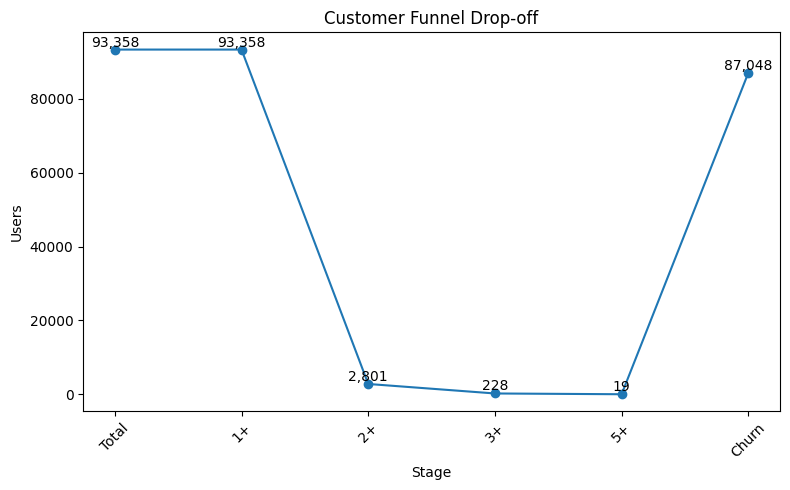

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(funnel['stage'], funnel['users'], marker='o')

plt.title('Customer Funnel Drop-off')
plt.xlabel('Stage')
plt.ylabel('Users')

for i, v in enumerate(funnel['users']):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
import plotly.graph_objects as go

funnel_no_total = funnel[funnel['stage'] != 'Total']
fig = go.Figure(go.Funnel(
    y = funnel_no_total['stage'],
    x = funnel_no_total['users'],
    textinfo = "value+percent initial"
))

fig.update_layout(
    title='Customer Funnel',
    width=700,
    height=500
)

fig.show()

In [ ]:
fig = go.Figure()

# Users
fig.add_trace(go.Bar(
    x=funnel['stage'],
    y=funnel['users'],
    name='Users',
    yaxis='y1'
))

# Conversion Rate
fig.add_trace(go.Scatter(
    x=funnel['stage'],
    y=funnel['conversion_rate'],
    name='Conversion Rate',
    yaxis='y2',
    mode='lines+markers'
))

fig.update_layout(
    title='Funnel Users & Conversion Rate',
    xaxis=dict(title='Stage'),

    yaxis=dict(title='Users'),

    yaxis2=dict(
        title='Conversion Rate',
        overlaying='y',
        side='right'
    )
)

fig.show()